# Lecture 8: Choosing hyperparameters

Can we improve a classifier by changing how it represents songs and how it draws a decision boundary? Using the Spotify dataset, we will tune an SVC pipeline and compare exhaustive and randomized search.

Our workflow: reserve a test set $\to$ establish a baseline $\to$ search with cross-validation $\to$ inspect the search $\to$ evaluate the selected model once. By the end, you should be able to explain nested parameter names, choose useful search ranges, and estimate a search's computational cost.

## 1. Set up the data and pipeline

Run this notebook from `content/classes/varada` using this directory's `.venv` kernel. Place `spotify.csv` in `data/`; it should contain the features listed below and a binary `target` column. Run the cells in order.

We use `pathlib.Path` to build paths. Preprocessing stays inside the pipeline so each cross-validation fold learns its scaler, categories, and vocabulary from that fold's training data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import loguniform, randint, uniform
from sklearn import set_config
from sklearn.compose import make_column_transformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import (
    GridSearchCV, ParameterGrid, RandomizedSearchCV, cross_validate, train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

%matplotlib inline
set_config(display="diagram")
pd.set_option("display.max_colwidth", 200)

DATA_DIR = Path.cwd() / "data"
data_path = DATA_DIR / "spotify.csv"
if not data_path.is_file():
    raise FileNotFoundError(
        f"Dataset not found: {data_path}. Start this notebook from "
        "content/classes/varada and place spotify.csv in data/."
    )

In [2]:
spotify_df = pd.read_csv(data_path, index_col=0)
X = spotify_df.drop(columns=["target", "artist"])
y = spotify_df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)
X_train.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,song_title
487,0.019300,0.352,248133,0.807,0.000006,0,0.0963,-7.781,1,0.1730,90.772,4.0,0.0459,Don't Die
215,0.030400,0.614,315000,0.838,0.000297,10,0.1660,-6.896,1,0.0280,127.971,4.0,0.5840,Come Save Me
1582,0.830000,0.534,238265,0.582,0.000000,2,0.1250,-6.220,1,0.0424,186.346,4.0,0.2890,No Le Digas Que Hacer
749,0.000076,0.597,343878,0.839,0.825000,7,0.5500,-6.964,1,0.0377,108.993,4.0,0.1990,Viol - Original Mix
587,0.040100,0.636,267147,0.702,0.000000,11,0.1050,-5.437,1,0.0743,125.998,4.0,0.4710,Hold Me Back


### One pipeline, several kinds of features

Scale continuous audio features, encode categorical features, pass through the binary mode, and count words in song titles. `CountVectorizer` takes a single column name so it receives a one-dimensional sequence of titles.

We will tune both the vocabulary size and the SVC's `C` and `gamma`. `C` controls regularization; `gamma` controls how local the RBF kernel's influence is.

In [3]:
numeric_feats = [
    "acousticness", "danceability", "energy", "instrumentalness",
    "liveness", "loudness", "speechiness", "tempo", "valence",
]
categorical_feats = ["time_signature", "key"]

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_feats),
    (OneHotEncoder(handle_unknown="ignore"), categorical_feats),
    ("passthrough", ["mode"]),
    (CountVectorizer(max_features=100, stop_words="english"), "song_title"),
)
pipe_svm = make_pipeline(preprocessor, SVC())
pipe_svm

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_thresh

In [4]:
CV = 5
baseline_scores = {}
for name, model in {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Default SVC": pipe_svm,
}.items():
    scores = cross_validate(model, X_train, y_train, cv=CV, scoring="accuracy")
    baseline_scores[name] = scores["test_score"].mean()
pd.Series(baseline_scores, name="Mean CV accuracy").to_frame()

,Mean CV accuracy
Dummy,0.505890
Default SVC,0.732164


## 2. Exhaustive grid search

`GridSearchCV` tries every combination in a parameter grid, using cross-validation to score each one. With `refit=True` (the default), it then fits the winning configuration on all the training data.

Nested parameter names follow the pipeline's structure: `svc__C` reaches the classifier, while `columntransformer__countvectorizer__max_features` reaches the text transformer. We start with powers of ten for `C` and `gamma` to explore different scales. `n_jobs=-1` runs fits across all available CPU cores.

In [5]:
param_grid = {
    "columntransformer__countvectorizer__max_features": [100, 400],
    "svc__gamma": [0.001, 0.01, 0.1, 10.0, 100.0],
    "svc__C": [0.001, 0.01, 1.0, 10.0, 100.0],
}
n_candidates = len(ParameterGrid(param_grid))
print(f"{n_candidates} configurations × {CV} folds = {n_candidates * CV} CV fits")
print("Plus one refit of the best configuration on all training data.")

grid_search = GridSearchCV(
    pipe_svm, param_grid, cv=CV, scoring="accuracy", n_jobs=-1,
    return_train_score=True,
)
grid_search.fit(X_train, y_train)

50 configurations × 5 folds = 250 CV fits
Plus one refit of the best configuration on all training data.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'columntransformer__countvectorizer__max_features': [100, 400], 'svc__C': [0.001, 0.01, ...], 'svc__gamma': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if`

### Read the results

`best_score_` is the winning mean validation accuracy, not test accuracy. Compare it with the baseline, then inspect the leading configurations. The training score helps reveal overfitting, and fit time shows the cost of each choice.

We use the same compact results table for every search below.

In [6]:
def search_results(search, top_n=10):
    columns = [
        "rank_test_score", "mean_test_score", "std_test_score",
        "mean_train_score", "mean_fit_time",
    ]
    results = pd.DataFrame(search.cv_results_)
    parameter_columns = [column for column in results if column.startswith("param_")]
    return results.sort_values("rank_test_score")[columns + parameter_columns].head(top_n)

print(f"Best grid CV accuracy: {grid_search.best_score_:.3f}")
display(grid_search.best_params_)
search_results(grid_search)

Best grid CV accuracy: 0.737


{'columntransformer__countvectorizer__max_features': 100,
 'svc__C': 1.0,
 'svc__gamma': 0.1}

,rank_test_score,mean_test_score,std_test_score,mean_train_score,mean_fit_time,param_columntransformer__countvectorizer__max_features,param_svc__C,param_svc__gamma
12,1,0.736509,0.021614,0.849194,0.030614,100,1.0,0.100
37,2,0.734652,0.027212,0.866554,0.036308,400,1.0,0.100
42,3,0.731540,0.013686,0.985741,0.049524,400,10.0,0.100
46,4,0.729048,0.020985,0.910879,0.049294,400,100.0,0.010
21,5,0.722235,0.023246,0.864383,0.046851,100,100.0,0.010
41,6,0.721633,0.027620,0.813236,0.036150,400,10.0,0.010
16,7,0.721631,0.024630,0.785648,0.031544,100,10.0,0.010
17,8,0.720378,0.014952,0.964971,0.044977,100,10.0,0.100
47,9,0.711705,0.015286,0.998605,0.053978,400,100.0,0.100
45,10,0.704286,0.021841,0.776350,0.036817,400,100.0,0.001


### Visualize the search without fitting again

Hold vocabulary size fixed and plot the mean validation accuracy for each `(C, gamma)` pair from the search we already ran. A bright region suggests useful values; a winner at an edge suggests the range may need to be extended.

Discuss: which hyperparameter seems more sensitive, and where would you search next?

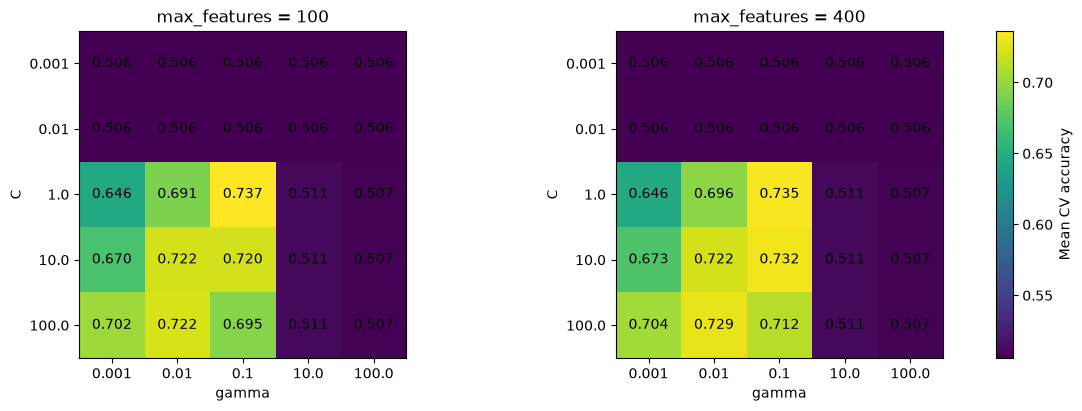

In [7]:
grid_results = pd.DataFrame(grid_search.cv_results_)
vocab_sizes = param_grid["columntransformer__countvectorizer__max_features"]
fig, axes = plt.subplots(1, len(vocab_sizes), figsize=(12, 4), constrained_layout=True)
vmin = grid_results["mean_test_score"].min()
vmax = grid_results["mean_test_score"].max()
for ax, vocab_size in zip(axes, vocab_sizes):
    subset = grid_results[
        grid_results["param_columntransformer__countvectorizer__max_features"] == vocab_size
    ]
    heatmap = subset.pivot(
        index="param_svc__C", columns="param_svc__gamma", values="mean_test_score"
    ).sort_index().sort_index(axis=1)
    image = ax.imshow(heatmap.to_numpy(), cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(heatmap.columns)), labels=heatmap.columns)
    ax.set_yticks(range(len(heatmap.index)), labels=heatmap.index)
    ax.set(xlabel="gamma", ylabel="C", title=f"max_features = {vocab_size}")
    for row in range(len(heatmap.index)):
        for col in range(len(heatmap.columns)):
            ax.text(col, row, f"{heatmap.iloc[row, col]:.3f}", ha="center", va="center")
fig.colorbar(image, ax=axes, label="Mean CV accuracy")
plt.show()

### Why the range and budget matter

A grid of large `gamma` values can miss a useful region completely. Start with a broad logarithmic range, then consider a finer search near promising values. Repeatedly adapting to the same CV results can also overfit the validation procedure, so keep the test set reserved.

The cost grows multiplicatively: five hyperparameters with ten values each give $10^5$ configurations. Five-fold CV would require 500,000 fits, plus the final refit.

For conditional choices, `param_grid` can be a list of dictionaries: an RBF SVC grid can include `C` and `gamma`, while a linear SVC grid needs only `C`.

## 3. Randomized search with a fixed budget

`RandomizedSearchCV` samples `n_iter` configurations instead of visiting the entire grid. First, use the same candidate values as the grid search so we can compare the methods within the same search space.

Here, 20 configurations require 100 CV fits. Set `random_state` to make the sampled configurations reproducible. A smaller budget saves computation but may miss the grid's winner.

In [8]:
list_search = RandomizedSearchCV(
    pipe_svm, param_distributions=param_grid, n_iter=20,
    cv=CV, scoring="accuracy", random_state=123, n_jobs=-1,
    return_train_score=True,
)
list_search.fit(X_train, y_train)
search_results(list_search)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,mean_fit_time,param_svc__gamma,param_svc__C,param_columntransformer__countvectorizer__max_features
7,1,0.736509,0.021614,0.849194,0.032019,0.100,1.0,100
3,2,0.729048,0.020985,0.910879,0.050722,0.010,100.0,400
10,3,0.722235,0.023246,0.864383,0.047593,0.010,100.0,100
13,4,0.721633,0.027620,0.813236,0.036024,0.010,10.0,400
11,5,0.711705,0.015286,0.998605,0.053985,0.100,100.0,400
12,6,0.691274,0.023758,0.720708,0.031653,0.010,1.0,100
6,7,0.672694,0.027217,0.696840,0.036896,0.001,10.0,400
0,8,0.646030,0.023857,0.657938,0.032430,0.001,1.0,100
1,9,0.510846,0.004895,0.999070,0.040821,10.000,1.0,100
4,9,0.510846,0.004895,0.999070,0.042897,10.000,10.0,100


### Sample distributions instead of a fixed list

A distribution lets us explore values between the grid points. For positive scale parameters such as `C` and `gamma`, a log-uniform distribution gives equal probability to equal intervals on a logarithmic scale: for example, `[0.01, 0.1]` and `[0.1, 1]`.

Compare the samples below. The log-uniform plot uses a logarithmic x-axis so you can see the coverage across orders of magnitude.

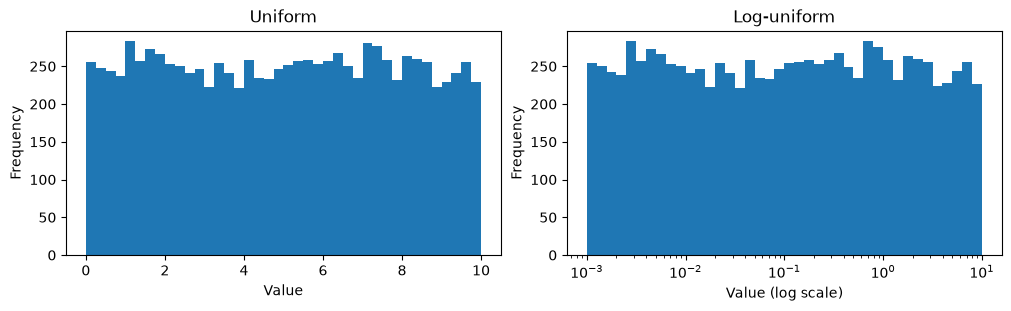

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
uniform_samples = uniform.rvs(loc=0.001, scale=10 - 0.001, size=10000, random_state=123)
log_samples = loguniform.rvs(0.001, 10, size=10000, random_state=123)
axes[0].hist(uniform_samples, bins=40)
axes[0].set(title="Uniform", xlabel="Value", ylabel="Frequency")
axes[1].hist(log_samples, bins=np.logspace(-3, 1, 41))
axes[1].set_xscale("log")
axes[1].set(title="Log-uniform", xlabel="Value (log scale)", ylabel="Frequency")
plt.show()

In [10]:
param_dist = {
    "columntransformer__countvectorizer__max_features": randint(100, 2001),
    "svc__C": loguniform(1e-3, 1e2),
    "svc__gamma": loguniform(1e-4, 1e2),
}
distribution_search = RandomizedSearchCV(
    pipe_svm, param_distributions=param_dist, n_iter=20,
    cv=CV, scoring="accuracy", random_state=123, n_jobs=-1,
    return_train_score=True,
)
distribution_search.fit(X_train, y_train)
search_results(distribution_search)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,mean_fit_time,param_columntransformer__countvectorizer__max_features,param_svc__C,param_svc__gamma
0,1,0.742082,0.029518,0.911810,0.040744,1634,3.670934,0.037224
2,2,0.737119,0.024524,0.930254,0.046064,1247,7.945822,0.029211
6,3,0.730919,0.031024,0.837104,0.040199,1192,1.441983,0.043807
7,4,0.727216,0.029449,0.843614,0.039411,440,0.454733,0.155226
10,5,0.720391,0.027847,0.793864,0.044026,1989,1.877615,0.017491
15,6,0.715432,0.027634,0.767671,0.034510,258,0.362090,0.061039
4,7,0.699329,0.022006,0.733728,0.038987,1042,1.369573,0.008809
13,8,0.699323,0.020737,0.743802,0.040386,926,0.294053,0.035891
3,9,0.688174,0.021291,0.713889,0.035072,213,0.253898,0.022527
8,10,0.686926,0.025892,0.707689,0.043470,604,0.030825,0.089641


### Compare the searches

Each search uses the same training split, folds, and accuracy metric. The distribution search explores a different space, so any score difference reflects both the sampling strategy and the available values.

Randomized search gives direct control over the number of configurations. When only a few parameters strongly affect performance, random sampling can explore more distinct values of those parameters than a grid with the same budget.

In [11]:
searches = {
    "Grid": grid_search,
    "Random (lists)": list_search,
    "Random (distributions)": distribution_search,
}
comparison = pd.DataFrame({
    name: {
        "Best CV accuracy": search.best_score_,
        "Configurations": len(search.cv_results_["params"]),
        "CV fits": len(search.cv_results_["params"]) * CV,
    }
    for name, search in searches.items()
}).T
comparison

,Best CV accuracy,Configurations,CV fits
Grid,0.736509,50.0,250.0
Random (lists),0.736509,20.0,100.0
Random (distributions),0.742082,20.0,100.0


## 4. Evaluate the selected model once

Choose the search with the highest CV score, then use its refitted model on the held-out test set. All model choices above used training data only. After viewing this test result, do not use it to revise the search.

Discuss: why can test accuracy differ from `best_score_`? The scores use different data, and selecting the best of many CV trials can make the winning CV score optimistic.

In [12]:
selected_name = max(searches, key=lambda name: searches[name].best_score_)
selected_search = searches[selected_name]
print(f"Selected search: {selected_name}")
display(selected_search.best_params_)
print(f"Best CV accuracy: {selected_search.best_score_:.3f}")
print(f"Held-out test accuracy: {selected_search.score(X_test, y_test):.3f}")

Selected search: Random (distributions)


{'columntransformer__countvectorizer__max_features': 1634,
 'svc__C': np.float64(3.67093422192648),
 'svc__gamma': np.float64(0.03722421578735051)}

Best CV accuracy: 0.742
Held-out test accuracy: 0.728


## Optional extension: successive halving

Successive halving starts many configurations with a small resource budget, drops weaker candidates, and increases resources for the survivors. Run this extension as a separate training-only experiment; it is not part of the model selection above.

With the default resource (`n_samples`), early rounds use fewer training examples. This can make rankings noisy, especially with small datasets.

In [13]:
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV

halving_search = HalvingRandomSearchCV(
    pipe_svm, param_distributions=param_dist, n_candidates=20,
    factor=2, cv=CV, scoring="accuracy", random_state=123,
    n_jobs=-1, return_train_score=True,
)
halving_search.fit(X_train, y_train)
search_results(halving_search)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,mean_fit_time,param_columntransformer__countvectorizer__max_features,param_svc__C,param_svc__gamma
38,1,0.713889,0.033157,0.785475,0.005007,1989,1.877615,0.017491
39,2,0.707589,0.042613,0.866884,0.006591,1192,1.441983,0.043807
0,3,0.683333,0.185592,0.987500,0.003240,1634,3.670934,0.037224
37,4,0.664718,0.063556,0.885482,0.003727,1192,1.441983,0.043807
35,5,0.664718,0.060193,0.819537,0.003979,1989,1.877615,0.017491
36,6,0.639516,0.079566,0.957677,0.004975,1634,3.670934,0.037224
24,7,0.600000,0.152613,0.796976,0.003645,1989,1.877615,0.017491
27,7,0.600000,0.152613,0.904839,0.004126,1192,1.441983,0.043807
2,9,0.583333,0.247207,1.000000,0.004018,1247,7.945822,0.029211
6,10,0.566667,0.177951,0.921667,0.003469,1192,1.441983,0.043807


### Beyond independent trials

Grid and randomized searches choose configurations independently of earlier scores. Bayesian optimization instead uses previous trials to guide the next choice. This is useful when individual fits are expensive, but it adds complexity beyond this demo.

Before leaving, explain: why does preprocessing belong inside CV, what does `n_iter` count, and why should we keep the test set out of the search?

## Optimization bias: finding a winner in noise

Can searching more models improve validation accuracy without improving predictions?

Generate **one dataset** with random features and independent random binary labels: true accuracy is 50%. Fit on 200 examples, select hyperparameters using the same 20 validation examples, and check the selected model on 1,000 independent test examples. With only 20 validation examples, one correct prediction changes accuracy by **5 percentage points**.

In [14]:
# Self-contained: keep the Spotify variables untouched.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterSampler
from sklearn.tree import DecisionTreeClassifier

BIAS_TRAIN_SIZE, BIAS_VALID_SIZE, BIAS_TEST_SIZE = 200, 20, 1000
BIAS_CANDIDATES = 1000
bias_rng = np.random.default_rng(1000)
bias_X = bias_rng.normal(size=(BIAS_TRAIN_SIZE + BIAS_VALID_SIZE + BIAS_TEST_SIZE, 20))
bias_y = bias_rng.integers(0, 2, size=len(bias_X))
bias_train_end = BIAS_TRAIN_SIZE
bias_valid_end = bias_train_end + BIAS_VALID_SIZE
bias_X_train, bias_y_train = bias_X[:bias_train_end], bias_y[:bias_train_end]
bias_X_valid, bias_y_valid = bias_X[bias_train_end:bias_valid_end], bias_y[bias_train_end:bias_valid_end]
bias_X_test, bias_y_test = bias_X[bias_valid_end:], bias_y[bias_valid_end:]

### Try 1,000 hyperparameter configurations

Sample tree depth, leaf size, feature count, splitting criterion, and splitting strategy. Keep the model's random seed fixed. After each trial, retain the model with the highest validation accuracy; ties keep the earlier winner.

Test scores are diagnostics only: they never influence selection.

In [15]:
bias_param_space = {
    "max_depth": np.arange(1, 16).tolist(),
    "min_samples_leaf": list(range(1, 21)),
    "max_features": [1, 2, 4, 8, 12, 16, 20, None],
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
}
bias_candidates = ParameterSampler(
    bias_param_space, n_iter=BIAS_CANDIDATES, random_state=2026
)
bias_best_validation = -np.inf
bias_records = []
for trial, params in enumerate(bias_candidates, start=1):
    model = DecisionTreeClassifier(**params, random_state=123)
    model.fit(bias_X_train, bias_y_train)
    validation_accuracy = model.score(bias_X_valid, bias_y_valid)
    if validation_accuracy > bias_best_validation:
        bias_best_validation = validation_accuracy
        bias_best_params = params
        bias_best_test = model.score(bias_X_test, bias_y_test)
    bias_records.append({
        "models_searched": trial,
        "validation_accuracy": bias_best_validation,
        "test_accuracy": bias_best_test,
    })
bias_results = pd.DataFrame(bias_records).set_index("models_searched")
bias_results.loc[[1, 5, 10, 25, 50, 100, 500, 1000]].round(3)

,validation_accuracy,test_accuracy
models_searched,,
1,0.45,0.518
5,0.70,0.504
10,0.75,0.511
25,0.75,0.511
50,0.85,0.502
100,0.85,0.502
500,0.85,0.502
1000,0.85,0.502


Selecting the highest validation score favours models that got lucky on these 20 examples. That luck does not transfer to new labels. This is **optimization bias**: we fit our model choice to validation noise.

This is one realization, so the exact gap depends on the dataset and candidates. On real data, searching may also improve predictions. Keep the final test set out of selection; using these test scores to revise the search would compromise it.

**Discuss:** Would a larger validation set reduce the gap?